In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nolasthitnotomorrow/radioml2016-deepsigcom/RML2016.10a_dict.pkl
/kaggle/input/notebooks/wykxldz/description-on-radioml-2016-10a/__results__.html
/kaggle/input/notebooks/wykxldz/description-on-radioml-2016-10a/__resultx__.html
/kaggle/input/notebooks/wykxldz/description-on-radioml-2016-10a/__notebook__.ipynb
/kaggle/input/notebooks/wykxldz/description-on-radioml-2016-10a/__output__.json
/kaggle/input/notebooks/wykxldz/description-on-radioml-2016-10a/custom.css


In [3]:
!pip install onnxruntime onnx -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 71.1 MB/s eta 0:00:00:00:0100:01


In [4]:
import os, glob, time, json, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

OUT = "/kaggle/working"   # only this folder is saved as notebook output

Using device: cuda


In [5]:
# Find the dataset file automatically so the exact folder name does not matter
matches = glob.glob("/kaggle/input/**/RML2016.10a_dict.pkl", recursive=True)
assert matches, "RadioML file not found. Add the dataset via Add Input first."
DATA_PATH = matches[0]
print("Using:", DATA_PATH)

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f, encoding="latin1")

mods = sorted(list(set(k[0] for k in data.keys())))
snrs = sorted(list(set(k[1] for k in data.keys())))
print("Modulations:", mods)
print("SNR levels:", snrs)
print("Sample shape:", data[(mods[0], snrs[0])].shape)

Using: /kaggle/input/datasets/nolasthitnotomorrow/radioml2016-deepsigcom/RML2016.10a_dict.pkl
Modulations: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR levels: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Sample shape: (1000, 2, 128)


In [6]:
X, y, snr_labels = [], [], []
for mod in mods:
    for snr in snrs:
        samples = data[(mod, snr)]
        X.append(samples)
        y += [mod] * samples.shape[0]
        snr_labels += [snr] * samples.shape[0]

X = np.vstack(X).astype(np.float32)
y = np.array(y)
snr_labels = np.array(snr_labels)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(
    X, y_encoded, snr_labels, test_size=0.2, random_state=SEED, stratify=y_encoded
)
print(X_train.shape, X_test.shape)

(176000, 2, 128) (44000, 2, 128)


In [7]:
class ModClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=8, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=8, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 128, kernel_size=4, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.squeeze(-1)
        return self.fc(x)

model = ModClassifierCNN(num_classes=len(mods)).to(device)
print(model)

ModClassifierCNN(
  (conv): Sequential(
    (0): Conv1d(2, 64, kernel_size=(8,), stride=(1,), padding=(4,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 128, kernel_size=(8,), stride=(1,), padding=(4,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(2,))
    (7): ReLU()
    (8): AdaptiveAvgPool1d(output_size=1)
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=11, bias=True)
  )
)


In [9]:
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256)

EPOCHS = 30
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS}: loss={total_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), f"{OUT}/model_weights.pth")
print("Model weights saved")

Epoch 1/30: loss=1.6844
Epoch 2/30: loss=1.6193
Epoch 3/30: loss=1.5525
Epoch 4/30: loss=1.4801
Epoch 5/30: loss=1.4136
Epoch 6/30: loss=1.3648
Epoch 7/30: loss=1.3389
Epoch 8/30: loss=1.3220
Epoch 9/30: loss=1.3143
Epoch 10/30: loss=1.3054
Epoch 11/30: loss=1.2897
Epoch 12/30: loss=1.2870
Epoch 13/30: loss=1.2827
Epoch 14/30: loss=1.2801
Epoch 15/30: loss=1.2764
Epoch 16/30: loss=1.2743
Epoch 17/30: loss=1.2725
Epoch 18/30: loss=1.2677
Epoch 19/30: loss=1.2674
Epoch 20/30: loss=1.2649
Epoch 21/30: loss=1.2568
Epoch 22/30: loss=1.2563
Epoch 23/30: loss=1.2534
Epoch 24/30: loss=1.2525
Epoch 25/30: loss=1.2513
Epoch 26/30: loss=1.2493
Epoch 27/30: loss=1.2501
Epoch 28/30: loss=1.2486
Epoch 29/30: loss=1.2495
Epoch 30/30: loss=1.2461
Model weights saved


In [10]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
fp32_torch_acc = 100 * correct / total
print(f"Overall PyTorch FP32 test accuracy: {fp32_torch_acc:.2f}%")

Overall PyTorch FP32 test accuracy: 52.64%


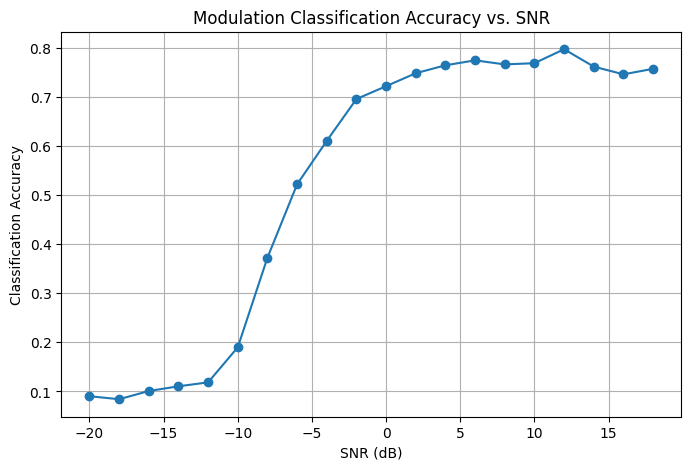

In [11]:
acc_by_snr = {}
with torch.no_grad():
    for snr in snrs:
        mask = snr_test == snr
        xb = torch.tensor(X_test[mask]).to(device)
        yb = torch.tensor(y_test[mask], dtype=torch.long).to(device)
        acc_by_snr[snr] = (model(xb).argmax(dim=1) == yb).float().mean().item()

plt.figure(figsize=(8, 5))
plt.plot(list(acc_by_snr.keys()), list(acc_by_snr.values()), marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Classification Accuracy")
plt.title("Modulation Classification Accuracy vs. SNR")
plt.grid(True)
plt.savefig(f"{OUT}/accuracy_vs_snr.png", dpi=150, bbox_inches="tight")
plt.show()

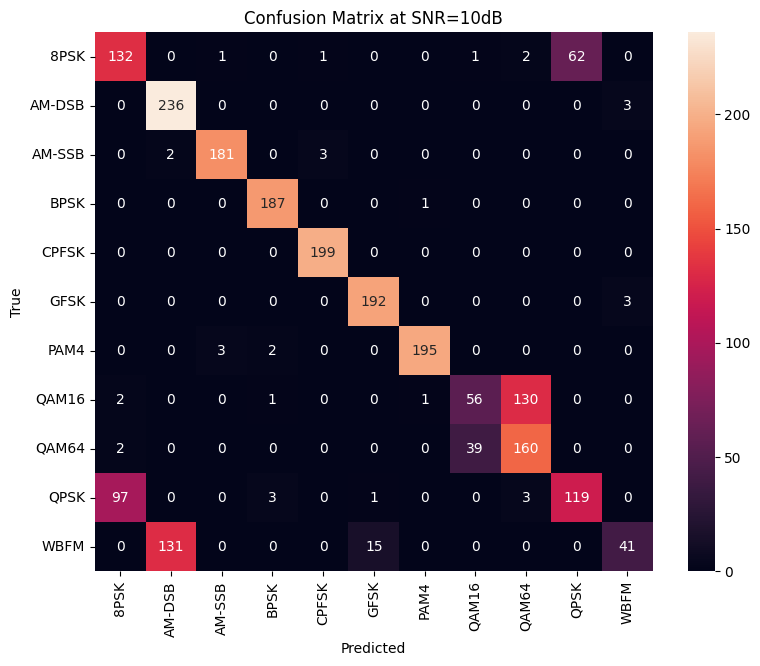

In [12]:
mask = snr_test == 10
with torch.no_grad():
    preds = model(torch.tensor(X_test[mask]).to(device)).argmax(dim=1).cpu().numpy()

cm = confusion_matrix(y_test[mask], preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix at SNR=10dB")
plt.savefig(f"{OUT}/confusion_matrix_10db.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
model.eval()
dummy_input = torch.randn(1, 2, 128).to(device)
FP32_PATH = f"{OUT}/mod_classifier.onnx"
torch.onnx.export(
    model, dummy_input, FP32_PATH,
    input_names=["input"], output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    dynamo=False,
)
print("Exported:", FP32_PATH)

/tmp/ipykernel_58/2446053631.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exported: /kaggle/working/mod_classifier.onnx


In [14]:
import onnxruntime as ort

def make_session(path):
    return ort.InferenceSession(path, providers=["CPUExecutionProvider"])

def benchmark(path, n_runs=500, warmup=20):
    sess = make_session(path)
    name = sess.get_inputs()[0].name
    dummy = np.random.randn(1, 2, 128).astype(np.float32)
    for _ in range(warmup):
        sess.run(None, {name: dummy})
    start = time.time()
    for _ in range(n_runs):
        sess.run(None, {name: dummy})
    return (time.time() - start) / n_runs * 1000   # ms per inference

def onnx_accuracy(path, batch=256):
    sess = make_session(path)
    name = sess.get_inputs()[0].name
    correct = 0
    for i in range(0, len(X_test), batch):
        out = sess.run(None, {name: X_test[i:i+batch]})[0]
        correct += (out.argmax(axis=1) == y_test[i:i+batch]).sum()
    return 100 * correct / len(X_test)

def size_kb(path):
    return os.path.getsize(path) / 1024

In [15]:
from onnxruntime.quantization import quantize_dynamic, QuantType

DYN_PATH = f"{OUT}/mod_classifier_dynamic_int8.onnx"
quantize_dynamic(FP32_PATH, DYN_PATH, weight_type=QuantType.QInt8)
print("Dynamic INT8 saved:", DYN_PATH)

Dynamic INT8 saved: /kaggle/working/mod_classifier_dynamic_int8.onnx


In [16]:
from onnxruntime.quantization import CalibrationDataReader, quantize_static, QuantFormat

class ModCalibrationReader(CalibrationDataReader):
    def __init__(self, calibration_data, input_name):
        self.data = calibration_data.astype(np.float32)
        self.input_name = input_name
        self.index = 0

    def get_next(self):
        if self.index >= len(self.data):
            return None
        if self.index % 20 == 0:
            print(f"Calibration sample {self.index}/{len(self.data)}")
        sample = self.data[self.index:self.index + 1]
        self.index += 1
        return {self.input_name: sample}

    def rewind(self):
        self.index = 0

STATIC_PATH = f"{OUT}/mod_classifier_static_int8.onnx"
calib_reader = ModCalibrationReader(X_train[:100], "input")

quantize_static(
    FP32_PATH, STATIC_PATH,
    calibration_data_reader=calib_reader,
    quant_format=QuantFormat.QDQ,
    weight_type=QuantType.QInt8,
    activation_type=QuantType.QInt8,
)
print("Static INT8 saved:", STATIC_PATH)

Calibration sample 0/100
Calibration sample 20/100
Calibration sample 40/100
Calibration sample 60/100
Calibration sample 80/100
Static INT8 saved: /kaggle/working/mod_classifier_static_int8.onnx


In [17]:
models = {
    "FP32": FP32_PATH,
    "Dynamic INT8": DYN_PATH,
    "Static INT8": STATIC_PATH,
}

results = {}
for label, path in models.items():
    results[label] = {
        "size_kb": round(size_kb(path), 1),
        "latency_ms": round(benchmark(path), 3),
        "accuracy_pct": round(float(onnx_accuracy(path)), 2),
    }

print(f"{'Model':<14}{'Size (KB)':>11}{'Latency (ms)':>15}{'Accuracy (%)':>15}")
for label, r in results.items():
    print(f"{label:<14}{r['size_kb']:>11}{r['latency_ms']:>15}{r['accuracy_pct']:>15}")

Model           Size (KB)   Latency (ms)   Accuracy (%)
FP32                589.4          0.202          52.64
Dynamic INT8        156.4          1.163           51.9
Static INT8         158.2          0.088          51.08


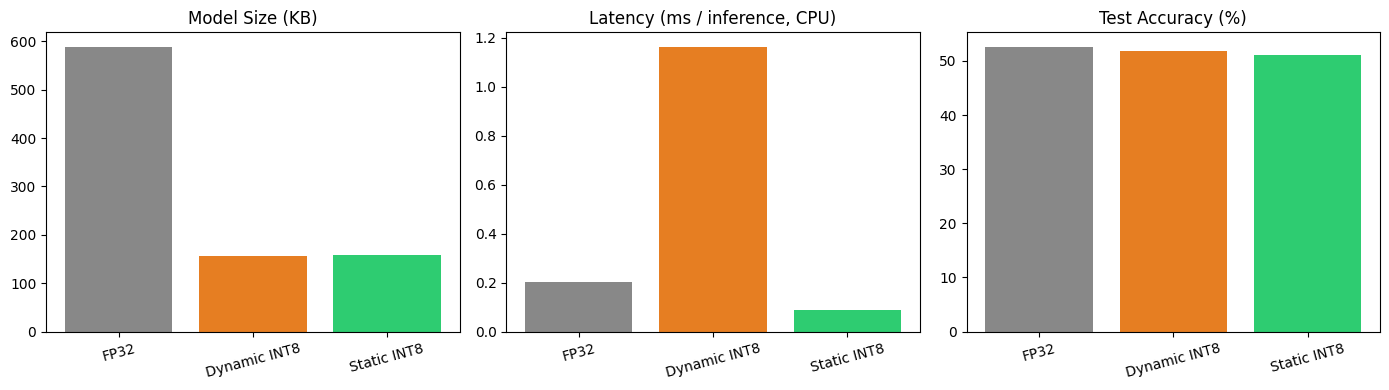

In [18]:
labels = list(results.keys())
colors = ["#888888", "#e67e22", "#2ecc71"]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].bar(labels, [results[l]["size_kb"] for l in labels], color=colors)
ax[0].set_title("Model Size (KB)")
ax[1].bar(labels, [results[l]["latency_ms"] for l in labels], color=colors)
ax[1].set_title("Latency (ms / inference, CPU)")
ax[2].bar(labels, [results[l]["accuracy_pct"] for l in labels], color=colors)
ax[2].set_title("Test Accuracy (%)")
for a in ax:
    a.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(f"{OUT}/quantization_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
sess = make_session(STATIC_PATH)
name = sess.get_inputs()[0].name

latencies = []
for sample in X_test[:1000]:
    s = sample[np.newaxis, :, :]
    t0 = time.time()
    sess.run(None, {name: s})
    latencies.append((time.time() - t0) * 1000)

stream = {
    "mean_latency_ms": round(float(np.mean(latencies)), 3),
    "max_latency_ms": round(float(np.max(latencies)), 3),
    "throughput_per_sec": round(float(1000 / np.mean(latencies)), 1),
}
print(stream)

{'mean_latency_ms': 0.099, 'max_latency_ms': 0.776, 'throughput_per_sec': 10140.7}


In [20]:
summary = {
    "pytorch_fp32_accuracy_pct": round(fp32_torch_acc, 2),
    "onnx_models": results,
    "streaming_static_int8": stream,
    "accuracy_by_snr": {str(k): round(v, 4) for k, v in acc_by_snr.items()},
}
with open(f"{OUT}/results.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print()
print("Files in output folder:")
for fn in sorted(os.listdir(OUT)):
    print(" ", fn)

{
  "pytorch_fp32_accuracy_pct": 52.64,
  "onnx_models": {
    "FP32": {
      "size_kb": 589.4,
      "latency_ms": 0.202,
      "accuracy_pct": 52.64
    },
    "Dynamic INT8": {
      "size_kb": 156.4,
      "latency_ms": 1.163,
      "accuracy_pct": 51.9
    },
    "Static INT8": {
      "size_kb": 158.2,
      "latency_ms": 0.088,
      "accuracy_pct": 51.08
    }
  },
  "streaming_static_int8": {
    "mean_latency_ms": 0.099,
    "max_latency_ms": 0.776,
    "throughput_per_sec": 10140.7
  },
  "accuracy_by_snr": {
    "-20": 0.0902,
    "-18": 0.084,
    "-16": 0.1008,
    "-14": 0.1104,
    "-12": 0.1185,
    "-10": 0.19,
    "-8": 0.3728,
    "-6": 0.5224,
    "-4": 0.611,
    "-2": 0.6963,
    "0": 0.7225,
    "2": 0.749,
    "4": 0.7651,
    "6": 0.7752,
    "8": 0.7669,
    "10": 0.7694,
    "12": 0.7979,
    "14": 0.7624,
    "16": 0.7467,
    "18": 0.7579
  }
}

Files in output folder:
  .virtual_documents
  accuracy_vs_snr.png
  confusion_matrix_10db.png
  mod_classifier